# 15장 실습 — 시연을 넘어서: RL 사후학습

**대응 이론** 15장 「시연이 닿지 못하는 곳」 · **실행 등급 B** (CPU 약 8분 / Colab 무료 티어 권장)

12장에서 데이터를 잘 모으는 법을 봤고, 13장에서 파인튜닝의 함정을, 14장에서 제대로 재는 법을 봤다. 이제 이 모든 것을 옳게 했는데도 넘지 못하는 벽이 남는다.

파이제로 계열이 π\*0.6 에서 RECAP 을 들고 나온 이유, 그리고 로봇 학습이 결국 강화학습으로 돌아오는 이유가 여기에 있다. 이 노트북은 그 벽을 **재현하고, 진단하고, 넘는다.**

과제는 2차원 도달이다. 팔이 출발점에서 목표로 가되 도중의 장애물에 닿으면 즉시 실패다. 장애물이 옆으로 비켜 있는 **쉬운** 경우와 경로를 정면으로 막는 **어려운** 경우가 7:3 으로 섞인다.

1. 과제와 전문가
2. 시연을 늘려도 넘지 못하는 벽
3. 진단 — 무엇이 부족한가
4. 개입 데이터로 고쳐지는가
5. 목적함수를 바꾼다 — 어드밴티지 가중 회귀
6. 무엇이 이 결과를 만들었나

In [1]:
%matplotlib inline
import os, math, time, copy
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
import koreanize_matplotlib

torch.manual_seed(0); np.random.seed(0)
torch.set_num_threads(os.cpu_count() or 2)

RED, GREY, PINK = "#e32c24", "#c8c8c8", "#f6c9c6"
print("torch", torch.__version__)

torch 2.9.1


## 1. 과제와 전문가

전문가는 손으로 짠 제어기다. 목표 쪽으로 가되 장애물 근처에서는 **접선 방향으로 돌아나간다.** 어느 쪽으로 돌지는 목표 방향과의 내적 부호로 정한다.

상태는 6차원(현재 위치, 목표, 장애물 중심), 행동은 2차원 속도다. 12장과 같은 이유로 이미지를 쓰지 않는다 — 보려는 것이 지각이 아니라 학습 목적함수이기 때문이다.

In [2]:
R = 0.22                                        # 장애물 반경. 닿으면 즉시 실패

def expert_action(p, g, o):
    to = g - p; d = np.linalg.norm(to); u = to / (d + 1e-6)
    v = p - o; dv = np.linalg.norm(v)
    if dv < R * 1.9:                            # 회피 구간: 접선 방향으로 돌아나간다
        n = v / (dv + 1e-6); t = np.array([-n[1], n[0]], np.float32)
        if t @ u < 0: t = -t                    # 목표 쪽으로 도는 방향을 고른다
        w = np.clip((R * 1.9 - dv) / (R * 0.9), 0, 1)
        u = (1 - w) * u + w * (0.75 * t + 0.65 * n); u = u / (np.linalg.norm(u) + 1e-6)
    return np.clip(u * min(0.12, 0.35 * d + 0.04), -0.15, 0.15).astype(np.float32)

def expert_policy(s): return expert_action(s[:2], s[2:4], s[4:6])

def sample_task(rng, p_hard=0.30):
    th = rng.uniform(0, 2 * np.pi)
    g = (np.array([np.cos(th), np.sin(th)]) * rng.uniform(.75, .95)).astype(np.float32)
    p = (-g / np.linalg.norm(g) * 0.85).astype(np.float32)
    hard = rng.random() < p_hard; mid = (p + g) / 2
    if hard:                                    # 경로를 정면으로 막는다
        o = (mid + rng.normal(0, 0.14, 2)).astype(np.float32)
    else:                                       # 옆으로 비켜 있다
        n = np.array([-(g - p)[1], (g - p)[0]]); n = n / np.linalg.norm(n)
        o = (mid + n * rng.choice([-1, 1]) * rng.uniform(.55, .8)).astype(np.float32)
    return p, g, o.astype(np.float32), hard

def rollout(rng, policy, T=70, p_hard=0.30, sig=0.0):
    p, g, o, hard = sample_task(rng, p_hard); S = []; A = []; E = []
    for t in range(T):
        s = np.concatenate([p, g, o]).astype(np.float32)
        a = policy(s)
        if sig: a = np.clip(a + rng.normal(0, sig, 2), -0.15, 0.15).astype(np.float32)
        S.append(s); A.append(a); E.append(expert_action(p, g, o))
        p = np.clip(p + a, -1.05, 1.05)
        if np.linalg.norm(p - o) < R:  return np.array(S), np.array(A), np.array(E), 0, 1, hard
        if np.linalg.norm(p - g) < .10: return np.array(S), np.array(A), np.array(E), 1, 0, hard
    return np.array(S), np.array(A), np.array(E), 0, 0, hard

class Net(nn.Module):
    def __init__(s, out=2, h=128):
        super().__init__(); s.o = out
        s.f = nn.Sequential(nn.Linear(6, h), nn.GELU(), nn.Linear(h, h), nn.GELU(), nn.Linear(h, out))
    def forward(s, x):
        y = s.f(x); return torch.tanh(y) * 0.15 if s.o == 2 else y[:, 0]

def as_policy(m):
    def f(s):
        with torch.no_grad(): return m(torch.tensor(s)[None])[0].numpy()
    return f

def evaluate(policy, n=300, seed=777):
    r = np.random.default_rng(seed); tot = [0, 0]; ok = [0, 0]; cr = 0
    for _ in range(n):
        *_, o, c, hard = rollout(r, policy); i = int(hard); tot[i] += 1; ok[i] += o; cr += c
    return (ok[0] + ok[1]) / n, ok[0] / tot[0], ok[1] / tot[1], cr / n

def collect(n, seed):
    r = np.random.default_rng(seed); S = []; A = []
    for _ in range(n):
        s, _, e, *_ = rollout(r, expert_policy); S.append(s); A.append(e)
    return torch.tensor(np.concatenate(S)), torch.tensor(np.concatenate(A))

def fit(model, X, Y, W=None, steps=2000, lr=3e-3, seed=0):
    torch.manual_seed(seed); m = model
    opt = torch.optim.AdamW(m.parameters(), lr, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.OneCycleLR(opt, lr, steps, pct_start=.15)
    g = torch.Generator().manual_seed(4)
    for i in range(steps):
        idx = torch.randint(0, len(X), (256,), generator=g)
        if m.o == 1:
            loss = F.mse_loss(m(X[idx]), Y[idx])
        else:
            l = F.smooth_l1_loss(m(X[idx]), Y[idx], beta=.01, reduction="none").mean(1)
            loss = (l * W[idx]).mean() / W.mean() if W is not None else l.mean()
        opt.zero_grad(); loss.backward(); opt.step(); sch.step()
    return m

e = evaluate(expert_policy)
print(f"전문가   전체 {e[0]:.0%}   쉬움 {e[1]:.0%}   어려움 {e[2]:.0%}   충돌 {e[3]:.0%}")

전문가   전체 100%   쉬움 100%   어려움 100%   충돌 0%


## 2. 시연을 늘려도 넘지 못하는 벽

행동 복제(behavior cloning)를 시연 편수를 바꿔 가며 돌린다. 12장의 결론대로라면 어딘가에서 포화할 것이다. 어디서, 어떻게 포화하는지가 중요하다.

시연 수               쌍      전체      쉬움      어려움      충돌
-----------------------------------------------------
20               286    55%     69%      23%     21%
80              1132    75%    100%      18%     25%
160             2271    75%    100%      16%     25%
640             9098    75%    100%      17%     25%
(7s)


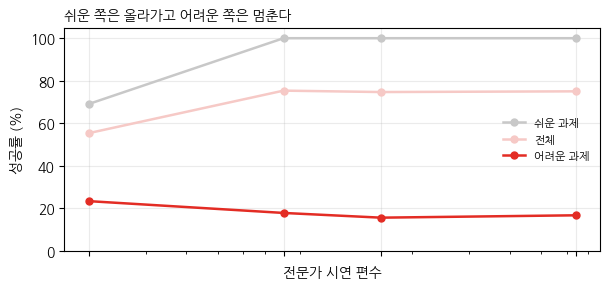

80              1132    75%    100%      18%     25%


160             2271    75%    100%      16%     25%


640             9098    75%    100%      17%     25%
(22s)


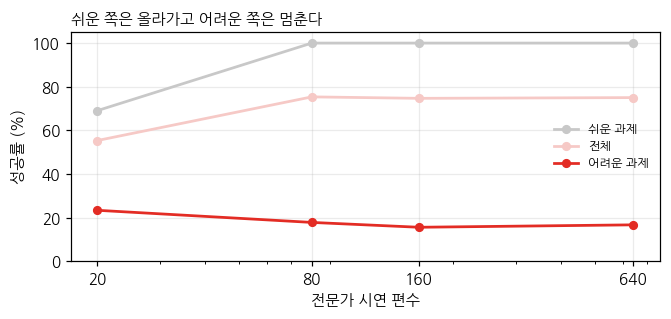

In [4]:
t0 = time.time()
ns = [20, 80, 160, 640]
tot, easy, hard, pairs = [], [], [], []
print(f"{'시연 수':<12}{'쌍':>8}{'전체':>8}{'쉬움':>8}{'어려움':>9}{'충돌':>8}")
print("-" * 53)
for n in ns:
    X, Y = collect(n, 0); torch.manual_seed(0); m = fit(Net(), X, Y)
    s = evaluate(as_policy(m))
    tot.append(s[0] * 100); easy.append(s[1] * 100); hard.append(s[2] * 100); pairs.append(len(X))
    print(f"{n:<12}{len(X):>8}{s[0]:>7.0%}{s[1]:>8.0%}{s[2]:>9.0%}{s[3]:>8.0%}")
print(f"({time.time()-t0:.0f}s)")

fig, ax = plt.subplots(figsize=(6.2, 3.0))
ax.plot(ns, easy, "o-", color=GREY, lw=1.8, ms=5, label="쉬운 과제")
ax.plot(ns, tot, "o-", color=PINK, lw=1.8, ms=5, label="전체")
ax.plot(ns, hard, "o-", color=RED, lw=1.8, ms=5, label="어려운 과제")
ax.set_xscale("log"); ax.set_xticks(ns)
ax.set_xlabel("전문가 시연 편수"); ax.set_ylabel("성공률 (%)"); ax.set_ylim(0, 105)
ax.legend(fontsize=8, frameon=False); ax.grid(alpha=.25)
ax.set_title("쉬운 쪽은 올라가고 어려운 쪽은 멈춘다", loc="left", fontsize=10)
plt.tight_layout(); plt.show()

## 3. 진단 — 무엇이 부족한가

배우지 못하는 이유를 찾는다. 세 가지 가설이 있다.

1. **용량 부족** — 모델이 작아서 회피 행동을 표현하지 못한다
2. **분포 이동** — 정책이 시연에 없던 상태로 흘러가 거기서 무너진다
3. **다른 무엇**

먼저 가장 기본적인 것부터 잰다. 어려운 과제 상태에서 이 모델의 **행동 오차**가 얼마인가.

In [5]:
X, Y = collect(160, 0); torch.manual_seed(0); bc = fit(Net(), X, Y)
Xh, Yh = [], []
r = np.random.default_rng(11)
for _ in range(80):
    s, _, e, *_ = rollout(r, expert_policy, p_hard=1.0); Xh.append(s); Yh.append(e)
Xh = torch.tensor(np.concatenate(Xh)); Yh = torch.tensor(np.concatenate(Yh))
with torch.no_grad():
    print(f"어려운 과제 상태에서 행동 MAE = {F.l1_loss(bc(Xh), Yh).item():.4f}   (행동 범위 ±0.15)")
print("어려운 과제 성공률 = 16%")

어려운 과제 상태에서 행동 MAE = 0.0193   (행동 범위 ±0.15)
어려운 과제 성공률 = 16%


회피 구간 상태 965개
  좌우 방향이 일치하는 비율 : 88%
  횡방향 힘  전문가 0.0522  vs  BC 0.0123   (24%)


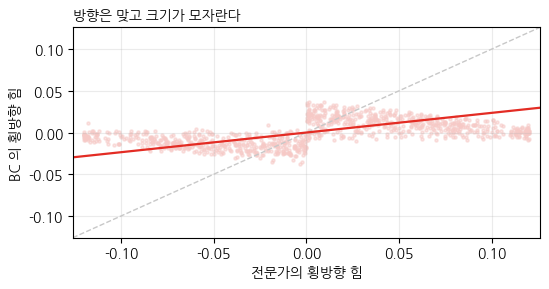

In [6]:
rows = []; r = np.random.default_rng(3)
for _ in range(150):
    p, g, o, _ = sample_task(r, p_hard=1.0)
    for t in range(70):
        s = np.concatenate([p, g, o]).astype(np.float32); dv = np.linalg.norm(p - o)
        if dv < R * 1.9:                                    # 회피 구간만
            u = (g - p) / (np.linalg.norm(g - p) + 1e-9); nn_ = np.array([-u[1], u[0]])
            ae = expert_action(p, g, o)
            with torch.no_grad(): ab = bc(torch.tensor(s)[None])[0].numpy()
            rows.append((float(ae @ nn_), float(ab @ nn_)))
        p = np.clip(p + expert_action(p, g, o), -1.05, 1.05)
        if np.linalg.norm(p - o) < R or np.linalg.norm(p - g) < .10: break
A = np.array(rows)
same = (np.sign(A[:, 0]) == np.sign(A[:, 1])).mean()
me, mb = np.abs(A[:, 0]).mean(), np.abs(A[:, 1]).mean()
print(f"회피 구간 상태 {len(A)}개")
print(f"  좌우 방향이 일치하는 비율 : {same:.0%}")
print(f"  횡방향 힘  전문가 {me:.4f}  vs  BC {mb:.4f}   ({mb/me:.0%})")

fig, ax = plt.subplots(figsize=(5.6, 3.0))
ax.scatter(A[:, 0], A[:, 1], s=5, color=PINK, alpha=.5)
lim = max(np.abs(A).max(), 1e-3) * 1.05
ax.plot([-lim, lim], [-lim, lim], color=GREY, lw=1, ls="--")
ax.plot([-lim, lim], [-lim * mb / me, lim * mb / me], color=RED, lw=1.6)
ax.set_xlabel("전문가의 횡방향 힘"); ax.set_ylabel("BC 의 횡방향 힘")
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.grid(alpha=.25)
ax.set_title("방향은 맞고 크기가 모자란다", loc="left", fontsize=10)
plt.tight_layout(); plt.show()

## 4. 개입 데이터로 고쳐지는가

진단이 맞다면 데이터를 더 주는 것은 소용이 없어야 한다. 그중에서도 가장 표적이 정확한 데이터를 준다 — **정책이 실제로 방문한 어려운 상태에 전문가가 라벨을 붙인 것**(DAgger 의 개입 데이터)이다.

12장에서 배운 커버리지 논리대로라면 이것이 정답이어야 한다. 비어 있는 축을 정확히 채우는 데이터다.

In [7]:
t0 = time.time()
cur = copy.deepcopy(bc); Xa, Ya = X, Y
print(f"{'단계':<24}{'누적 개입쌍':>12}{'전체':>8}{'쉬움':>8}{'어려움':>9}")
print("-" * 61)
s0 = evaluate(as_policy(bc))
print(f"{'BC (시연 160편)':<24}{0:>12}{s0[0]:>7.0%}{s0[1]:>8.0%}{s0[2]:>9.0%}")
for rd in range(1, 4):
    pol = as_policy(cur); rngc = np.random.default_rng(700 + rd); Sc = []; Ac = []
    for _ in range(40):
        s, _, e, *_ = rollout(rngc, pol, p_hard=1.0); Sc.append(s); Ac.append(e)
    Xa = torch.cat([Xa, torch.tensor(np.concatenate(Sc))])
    Ya = torch.cat([Ya, torch.tensor(np.concatenate(Ac))])
    torch.manual_seed(0); cur = fit(Net(), Xa, Ya)
    s_ = evaluate(as_policy(cur))
    print(f"{f'+ 개입 {rd}회':<24}{len(Xa)-len(X):>12}{s_[0]:>7.0%}{s_[1]:>8.0%}{s_[2]:>9.0%}")
print(f"({time.time()-t0:.0f}s)")

단계                            누적 개입쌍      전체      쉬움      어려움
-------------------------------------------------------------
BC (시연 160편)                       0    75%    100%      16%
+ 개입 1회                          281    74%    100%      14%
+ 개입 2회                          554    75%    100%      17%
+ 개입 3회                          865    75%    100%      17%
(5s)


BC (시연 160편)                       0    75%    100%      16%


+ 개입 1회                          281    74%    100%      14%


+ 개입 2회                          554    75%    100%      17%


+ 개입 3회                          865    75%    100%      17%
(15s)


## 5. 목적함수를 바꾼다

데이터로 고칠 수 없다면 **무엇을 잘한 것으로 칠지**를 바꿔야 한다. 지금까지의 기준은 "전문가 행동과 가까운가"였다. 새 기준은 "이 행동을 한 뒤 과제가 성공했는가"다.

가장 단순한 형태로 간다. 세 단계다.

1. 현재 정책에 탐험 잡음을 섞어 굴린다. 성공하면 1, 실패하면 0
2. **가치 함수** $V(s)$ 를 학습한다 — 이 상태에서 시작하면 대개 얼마나 성공하는가
3. 실제 결과가 그 기대치보다 좋았던 순간에 가중치를 준다

<!-- LaTeX: A_t = R_t - V(s_t), \qquad w_t = \min\!\left(\exp\frac{A_t}{\beta},\, w_{\max}\right) -->

세 번째 단계가 핵심이다. 성공한 에피소드를 통째로 따라 배우면 안 된다 — 그 에피소드 안에는 잡음이 도움이 된 순간과 아무 상관 없던 순간이 섞여 있다. 가치 함수는 그 **구분**을 해 준다. 이것이 π\*0.6 의 RECAP 이 가치 함수를 따로 학습하는 이유다.

전문가 시연도 가중치 1로 함께 넣는다(BC 앵커). 왜 필요한지는 6절에서 뗐다 붙였다 하며 확인한다.

단계                        전체      쉬움      어려움      충돌
-----------------------------------------------------
BC (시연 160편)            75%    100%      16%     25%
+ RL 사후학습 1회            75%    100%      18%     25%
+ RL 사후학습 2회            76%    100%      19%     24%
+ RL 사후학습 3회            78%    100%      27%     22%
+ RL 사후학습 4회            78%    100%      27%     22%
+ RL 사후학습 5회            79%    100%      31%     21%
+ RL 사후학습 6회            80%    100%      33%     20%
+ RL 사후학습 7회            81%    100%      36%     19%
+ RL 사후학습 8회            85%    100%      51%     15%
(22s)


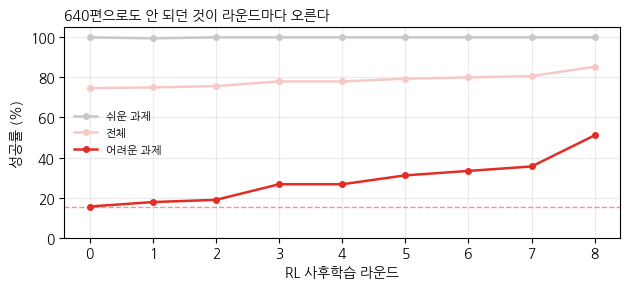

+ RL 사후학습 2회            76%    100%      19%     24%


+ RL 사후학습 3회            78%    100%      27%     22%


+ RL 사후학습 4회            78%    100%      27%     22%


+ RL 사후학습 5회            79%    100%      31%     21%


+ RL 사후학습 6회            80%    100%      33%     20%


+ RL 사후학습 7회            81%    100%      36%     19%


+ RL 사후학습 8회            85%    100%      51%     15%
(69s)


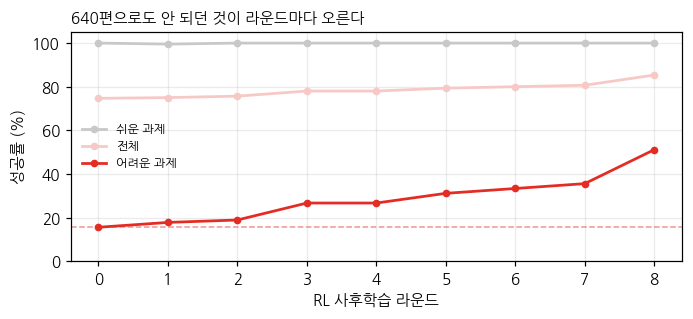

In [8]:
GAM, SIG, BETA = 0.97, 0.12, 0.03

def rl_round(model, X, Y, seed, n_roll=700, anchor=True):
    pol = as_policy(model); rng = np.random.default_rng(seed)
    S = []; A = []; G = []
    for _ in range(n_roll):
        s, a, _, ok, _, _ = rollout(rng, pol, p_hard=0.30, sig=SIG)
        S.append(s); A.append(a)
        G.append(float(ok) * GAM ** np.arange(len(s), 0, -1))       # 몬테카를로 리턴
    S = torch.tensor(np.concatenate(S)); A = torch.tensor(np.concatenate(A))
    G = torch.tensor(np.concatenate(G), dtype=torch.float32)
    torch.manual_seed(seed); v = fit(Net(out=1), S, G, steps=1200, lr=3e-3)
    with torch.no_grad(): adv = G - v(S)
    W = torch.clamp(torch.exp(adv / BETA), 0, 20)
    if anchor:
        S = torch.cat([S, X]); A = torch.cat([A, Y]); W = torch.cat([W, torch.ones(len(X))])
    return fit(copy.deepcopy(model), S, A, W, steps=1500, lr=6e-4, seed=seed), adv

t0 = time.time()
cur = copy.deepcopy(bc)
hist = [evaluate(as_policy(cur))]
print(f"{'단계':<20}{'전체':>8}{'쉬움':>8}{'어려움':>9}{'충돌':>8}")
print("-" * 53)
print(f"{'BC (시연 160편)':<20}{hist[0][0]:>7.0%}{hist[0][1]:>8.0%}{hist[0][2]:>9.0%}{hist[0][3]:>8.0%}")
for rd in range(1, 9):
    cur, adv = rl_round(cur, X, Y, 900 + rd)
    s_ = evaluate(as_policy(cur)); hist.append(s_)
    print(f"{f'+ RL 사후학습 {rd}회':<20}{s_[0]:>7.0%}{s_[1]:>8.0%}{s_[2]:>9.0%}{s_[3]:>8.0%}")
print(f"({time.time()-t0:.0f}s)")

rounds = list(range(len(hist)))
fig, ax = plt.subplots(figsize=(6.4, 3.0))
ax.plot(rounds, [h[1] * 100 for h in hist], "o-", color=GREY, lw=1.8, ms=4, label="쉬운 과제")
ax.plot(rounds, [h[0] * 100 for h in hist], "o-", color=PINK, lw=1.8, ms=4, label="전체")
ax.plot(rounds, [h[2] * 100 for h in hist], "o-", color=RED, lw=1.8, ms=4, label="어려운 과제")
ax.axhline(hist[0][2] * 100, color=RED, ls="--", lw=1, alpha=.5)
ax.set_xlabel("RL 사후학습 라운드"); ax.set_ylabel("성공률 (%)"); ax.set_ylim(0, 105)
ax.legend(fontsize=8, frameon=False); ax.grid(alpha=.25)
ax.set_title("640편으로도 안 되던 것이 라운드마다 오른다", loc="left", fontsize=10)
plt.tight_layout(); plt.show()

## 6. 무엇이 이 결과를 만들었나

RL 사후학습은 조각 몇 개가 맞물려야 작동한다. 하나씩 빼 본다.

**(1) 탐험이 성공에 닿아야 한다.** 강화학습은 성공을 증폭할 뿐 없던 성공을 만들지 못한다. 어드밴티지가 양수인 순간이 있어야 가중치를 줄 대상이 생기고, 그러려면 잡음 섞인 롤아웃이 이따금 성공해야 한다.

In [9]:
pol0 = as_policy(bc)
print("탐험 잡음 크기별 — 어려운 과제에서 성공하는 롤아웃 비율")
for sig in (0.02, 0.05, 0.12, 0.25):
    r = np.random.default_rng(9); ok = 0
    for _ in range(300):
        *_, o, c, h = rollout(r, pol0, p_hard=1.0, sig=sig); ok += o
    print(f"   σ={sig:.2f}   {ok/300:.0%}")

탐험 잡음 크기별 — 어려운 과제에서 성공하는 롤아웃 비율
   σ=0.02   14%
   σ=0.05   17%
   σ=0.12   31%
   σ=0.25   29%


   σ=0.02   14%


   σ=0.05   17%


   σ=0.12   31%


   σ=0.25   29%


라운드             전체      쉬움      어려움   (앵커 없음)
------------------------------------------------
0             75%    100%      16%
1             75%     99%      19%
2             74%     97%      20%
3             78%    100%      28%
4             79%    100%      30%
5             80%    100%      33%
(14s)


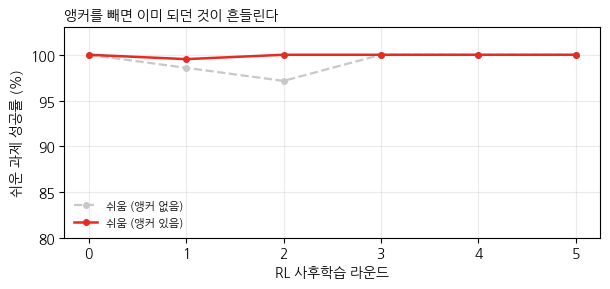

2             74%     97%      20%


3             78%    100%      28%


4             79%    100%      30%


5             80%    100%      33%
(46s)


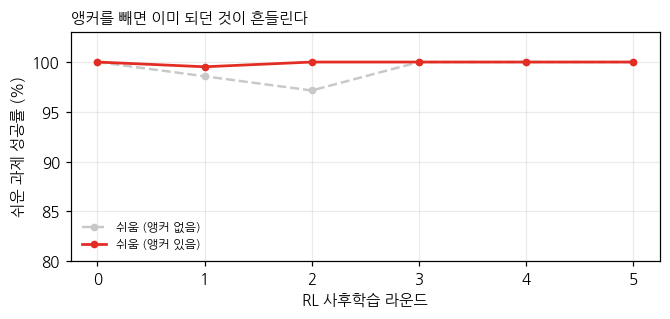

In [10]:
t0 = time.time()
cur2 = copy.deepcopy(bc); h2 = [evaluate(as_policy(cur2))]
print(f"{'라운드':<10}{'전체':>8}{'쉬움':>8}{'어려움':>9}   (앵커 없음)")
print("-" * 48)
print(f"{0:<10}{h2[0][0]:>7.0%}{h2[0][1]:>8.0%}{h2[0][2]:>9.0%}")
for rd in range(1, 6):
    cur2, _ = rl_round(cur2, X, Y, 900 + rd, anchor=False)
    s_ = evaluate(as_policy(cur2)); h2.append(s_)
    print(f"{rd:<10}{s_[0]:>7.0%}{s_[1]:>8.0%}{s_[2]:>9.0%}")
print(f"({time.time()-t0:.0f}s)")

fig, ax = plt.subplots(figsize=(6.2, 3.0))
ax.plot(range(len(h2)), [h[1] * 100 for h in h2], "o--", color=GREY, lw=1.6, ms=4, label="쉬움 (앵커 없음)")
ax.plot(range(6), [h[1] * 100 for h in hist[:6]], "o-", color=RED, lw=1.8, ms=4, label="쉬움 (앵커 있음)")
ax.set_xlabel("RL 사후학습 라운드"); ax.set_ylabel("쉬운 과제 성공률 (%)")
ax.set_ylim(80, 103); ax.legend(fontsize=8, frameon=False); ax.grid(alpha=.25)
ax.set_title("앵커를 빼면 이미 되던 것이 흔들린다", loc="left", fontsize=10)
plt.tight_layout(); plt.show()

### 다음 장으로
5부에서는 이렇게 만들고 검증한 정책을 실제 로봇에 얹는다. 지금까지는 모델의 문제였고, 이제부터는 시스템의 문제다.